# Radial Basis Function (RBF) Networks

## Equipo 8:

* Andres Camilo Torres Cajamarca (antorresca@unal.edu.co)
* Adrian Ramirez Gonzalez (adramirez@unal.edu.co)
* Andres Felipe Poveda Bellon (anpovedab@unal.edu.co)
* Jorge Aurelio Morales Manrique (jomorales@unal.edu.co)
* Miguel Angel Pinzon Garcia (mipinzong@unal.edu.co)

---
## 1. ¿Qué es una RBF Network?

<div align='justify'>

Una **Radial Basis Function Network (RBFN)** es un tipo de red neuronal utilizada principalmente para aproximación de funciones, regresión y clasificación.

Su característica principal es que las neuronas de la capa oculta utilizan funciones radiales como función de activación, siendo la más común la función gaussiana.

A diferencia de otras redes neuronales, en una RBF la activación de una neurona depende de la distancia entre la entrada y un punto específico llamado centro. Esto significa que cada neurona responde fuertemente solo a regiones locales del espacio de entrada.

Las redes neuronales tradicionales utilizan funciones de activación como ReLU, sigmoid o tanh y aprenden representaciones a través de transformaciones globales del espacio de entrada.

Las RBF, en cambio, utilizan funciones basadas en distancias, lo que produce un comportamiento local.

### Usos típicos

Las RBF Networks se aplican con éxito en una variedad de problemas:

| Tarea | Descripción | Ejemplo en este notebook |
|-------|-------------|---------------------------|
| **Regresión** | Predicción de valores continuos a partir de entradas | Aproximar $\frac{x^2+y^2}{50}$ (Ejemplo 1) |
| **Clasificación** | Asignación de etiquetas de clase | Reconocimiento de dígitos MNIST (Ejemplo 2) |
| **Aproximación de funciones** | Modelar relaciones no lineales complejas | Interpolación multivariable |

</div>

<div align='center'>

![image.png](https://docs.tibco.com/pub/stat/14.0.0/doc/html/UsersGuide/GUID-05F0B3B8-530D-47D5-997A-146C1E366083-display.jpg)

</div>

## 2. Arquitectura de una RBF Network

<div align='justify'>

Una Radial Basis Function Network (RBFN) está compuesta por **tres capas** que procesan la información de forma secuencial:

| Capa | Rol | Característica clave |
|------|-----|----------------------|
| **Entrada** | Recibe el vector de características $x$ | Pasiva: solo transmite datos, sin cálculos |
| **Oculta** | Aplica una transformación no lineal al espacio de entrada | Cada neurona mide la distancia entre $x$ y un centro aprendido |
| **Salida** | Combina linealmente las activaciones de la capa oculta | Los únicos pesos entrenables de la red |

El principio clave es la separación entre **transformación** y **combinación**: la capa oculta transforma el espacio de entrada en una representación donde el problema es más fácil de resolver, y la capa de salida aplica una suma ponderada sobre esa representación. Esto permite entrenar la red en dos etapas independientes.

El flujo general de la red puede representarse como:

</div>

<div align='center'>

<img src='https://chrisjmccormick.wordpress.com/wp-content/uploads/2013/08/architecture_simple2.png' width=500/>

</div>

### a. Capa de entrada

<div align='justify'>

La capa de entrada recibe el vector de características del problema.

Si el problema tiene
$n$ variables de entrada, entonces el vector de entrada puede representarse como:

$$x = (x_1, x_2, \ldots, x_n)$$

Esta capa no realiza cálculos, simplemente transmite los datos hacia la capa oculta.

### b. Capa oculta (funciones radiales)

La capa oculta es el elemento más característico de las RBF Networks. Está formada por $K$ neuronas, donde $K$ es un **hiperparámetro de diseño** elegido por el usuario; una mayor $K$ permite aproximar funciones más complejas, aunque también aumenta el costo computacional.

Cada neurona $i$ queda definida por dos parámetros:

* un **centro** $c_i \in \mathbb{R}^n$: el punto del espacio de entrada alrededor del cual la neurona es sensible. Los centros se determinan a partir de los datos de entrenamiento (véase la sección 4).
* un **parámetro de anchura** $\sigma_i > 0$: controla qué tan amplia o estrecha es la zona de influencia de la neurona.

La función radial más utilizada es la **función gaussiana**:

$$\phi(x) = e^{-\frac{||x-c||^{2}}{2\sigma^{2}}}$$

Su comportamiento es:

* si la entrada $x$ está **cerca** del centro $c$: activación $\phi(x) \approx 1$ (alta)
* si la entrada $x$ está **lejos** del centro $c$: activación $\phi(x) \approx 0$ (baja)

Cada neurona actúa como un **detector local de patrones**: solo se activa ante entradas dentro de su región de influencia. El widget interactivo a continuación permite explorar este comportamiento ajustando el centro y la anchura $\sigma$.

</div>

In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_rbf(center=0.0, sigma=1.0):

    x = np.linspace(-10, 10, 400)
    y = np.exp(-(x-center)**2/(2*sigma**2))

    plt.figure(figsize=(6,4))
    plt.plot(x, y)
    plt.title("Función Radial Gaussiana")
    plt.xlabel("x")
    plt.ylabel("φ(x)")
    plt.ylim(-0.1, 1.1)
    plt.axvline(center, linestyle="--", label="Centro")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

interact(
    plot_rbf,
    center=FloatSlider(min=-5, max=5, step=0.1, value=0),
    sigma=FloatSlider(min=0.1, max=5, step=0.1, value=1)
);

interactive(children=(FloatSlider(value=0.0, description='center', max=5.0, min=-5.0), FloatSlider(value=1.0, …

<div align='justify'>

### c. Capa de salida

La capa de salida realiza una **combinación lineal** de las activaciones producidas por las $K$ neuronas de la capa oculta:

$$y = \sum_{i=1}^{K} w_i \, \phi_i(x)$$

donde $w_i$ son los pesos de salida y $\phi_i(x)$ es la activación de la $i$-ésima neurona RBF ante la entrada $x$.

Esta capa es **lineal por diseño**, lo que tiene dos consecuencias importantes:

1. Las conexiones entre la capa de entrada y la capa oculta son **directas y sin pesos**. Los únicos parámetros entrenables de la red son los pesos de salida $w_i$.
2. El ajuste de los $w_i$ es un **problema de mínimos cuadrados**, resoluble de forma eficiente (véase la sección 5).

Según la tarea:

| Tarea | Interpretación de la salida $y$ |
|-------|---------------------------------|
| Regresión | Valor continuo predicho |
| Clasificación | Puntuación por clase; se asigna la etiqueta de mayor puntuación |

</div>

In [2]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, VBox, HBox, interactive_output, HTML
from IPython.display import display
from sklearn.cluster import KMeans

def rbf(x, c, sigma):
    return np.exp(-(x-c)**2/(2*sigma**2))

def demo(c1, c2, c3, s1, s2, s3, w1, w2, w3):

    x = np.linspace(-10,10,400)

    phi1 = rbf(x,c1,s1)
    phi2 = rbf(x,c2,s2)
    phi3 = rbf(x,c3,s3)

    y = w1*phi1 + w2*phi2 + w3*phi3

    fig, ax = plt.subplots(1,2, figsize=(14,5))

    ax[0].plot(x,phi1,label="RBF1", linewidth=2)
    ax[0].plot(x,phi2,label="RBF2", linewidth=2)
    ax[0].plot(x,phi3,label="RBF3", linewidth=2)
    ax[0].set_title("Funciones Radiales")
    ax[0].legend()
    ax[0].grid(True) # Added grid

    ax[1].plot(x,y, label="Salida de la red")
    ax[1].set_title("Salida de la red (suma ponderada)")
    ax[1].legend()
    ax[1].grid(True)

    plt.show()

c1 = FloatSlider(value=-5, min=-10, max=10, step=0.1, description='c1')
c2 = FloatSlider(value=0, min=-10, max=10, step=0.1, description='c2')
c3 = FloatSlider(value=5, min=-10, max=10, step=0.1, description='c3')

s1 = FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ1')
s2 = FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ2')
s3 = FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ3')

w1 = FloatSlider(value=1, min=-5, max=5, step=0.1, description='w1')
w2 = FloatSlider(value=1, min=-5, max=5, step=0.1, description='w2')
w3 = FloatSlider(value=1, min=-5, max=5, step=0.1, description='w3')

centros = VBox([HTML("<b>Centros</b>"),c1, c2, c3])
sigmas = VBox([HTML("<b>Anchura</b>"),s1, s2, s3])
pesos = VBox([HTML("<b>Pesos</b>"),w1, w2, w3])

display(HBox([centros, sigmas, pesos]))

out = interactive_output(
    demo,
    {
        'c1': c1,
        'c2': c2,
        'c3': c3,
        's1': s1,
        's2': s2,
        's3': s3,
        'w1': w1,
        'w2': w2,
        'w3': w3
    }
)

display(out)


Output()

## 3. Funcion de base radial (RBF)

Este tipo de funciones toman como entrada la norma entre un punto de entrada x y un punto fijo $x_i$

$$
Φ(||x-x_i||) = Φ(r)
$$

Aunque la funcion Gaussiana es la mas comun, tambien existen otras funciones de base radial:

* Funcion multicuadratica: $ Φ(r) = (r^2 + c^2)^{1/2} $
* Funcion multicuadratica inversa: $ Φ(r) = \frac{1}{(r^2 + c^2)^{1/2}} $

 La busqueda de estos puntos fijos para cada neurona hara parte del proceso de aprendizaje de la red neuronal. Tambien es importante recalcar que en este tipo de red neuronal unicamente las conexiones entre la capa oculta y la capa de salida tienen pesos asociados (es decir, no existen pesos asociados a las conexiones entre la capa de entrada y la capa oculta)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from matplotlib.patches import Circle

In [4]:
def distance(x, c):
  """Calcula distancia euclidiana entre x y c"""

  return np.linalg.norm(x - c, axis=1)

def gaussian(x, c, sigma):
  """Calcula el valor de la funcion gaussiana evaluada en x usando el centro c y sigma"""

  return np.exp(-((distance(x,c)**2)/(2 * sigma**2)))

def multiquadrics(x,c, p):
  """Calcula el valor de la funcion multicuadratica evaluada en x usando el centro c y el valor p"""

  return np.sqrt(distance(x,c)**2 + p**2)

def inverse_multiquadrics(x,c,p):
  """Calcula el valor de la funcion multicuadratica inversa evaluada en x usando el centro c y el valor p"""

  return 1/multiquadrics(x,c,p)

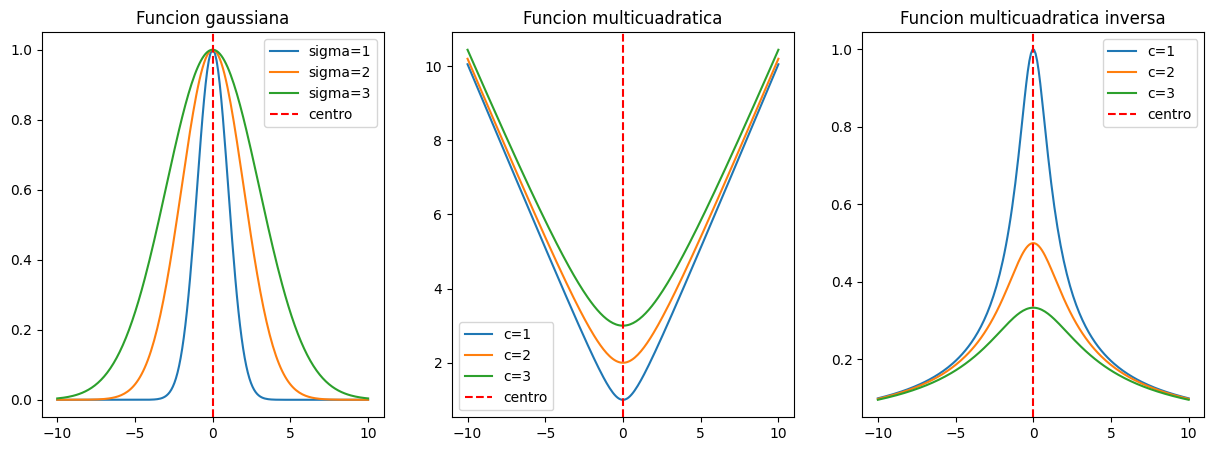

In [5]:
center = 0
sigma = 1
c = 1

x = np.linspace(-10,10,200).reshape(-1,1)
gauss_1 = gaussian(x, center, sigma)
gauss_2 = gaussian(x, center, sigma+1)
gauss_3 = gaussian(x, center, sigma+2)

mult_1 = multiquadrics(x, center, c)
mult_2 = multiquadrics(x, center, c+1)
mult_3 = multiquadrics(x, center, c+2)

inv_mult_1 = inverse_multiquadrics(x, center, c)
inv_mult_2 = inverse_multiquadrics(x, center, c+1)
inv_mult_3 = inverse_multiquadrics(x, center, c+2)

fig, axs = plt.subplots(1,3, figsize=(15,5))

axs[0].plot(x, gauss_1, label=f"sigma={sigma}")
axs[0].plot(x, gauss_2, label=f"sigma={sigma+1}")
axs[0].plot(x, gauss_3, label=f"sigma={sigma+2}")
axs[0].set_title("Funcion gaussiana")
axs[0].axvline(x=center, c="r", label="centro", ls='--')
axs[0].legend()

axs[1].plot(x, mult_1, label=f"c={c}")
axs[1].plot(x, mult_2, label=f"c={c+1}")
axs[1].plot(x, mult_3, label=f"c={c+2}")
axs[1].set_title("Funcion multicuadratica")
axs[1].axvline(x=center, c="r", label="centro", ls='--')
axs[1].legend()

axs[2].plot(x, inv_mult_1, label=f"c={c}")
axs[2].plot(x, inv_mult_2, label=f"c={c+1}")
axs[2].plot(x, inv_mult_3, label=f"c={c+2}")
axs[2].set_title("Funcion multicuadratica inversa")
axs[2].axvline(x=center, c="r", label="centro", ls='--')
axs[2].legend()

plt.show()


### 3.1 Campo receptivo

El campo receptivo se refiere a una region donde, al generar un estimulo lo suficientemente notable, se obtendra una respuesta. En este caso, gracias a las funciones de base radial podemos modelar el campo receptivo de una forma muy sencilla.  

En general, el campo receptivo se define de la siguiente manera:

$$
Ψ(x) = Φ(x,x_j) - a
$$

Esta funcion permite definir un espacio donde el valor de la funcion de base radial genera valores mayores o iguales a la constante a.

Para el caso de la funcion Gaussiana en 2 dimensiones este campo receptivo es una region en forma de circulo con radio $σ\sqrt{2log(\frac{1}{a})}$


In [32]:
x = np.array([2, 3, 8])
y = np.array([4, 8, 7])
sigma = 2

@interact(xNew=(0,10,0.01), yNew=(0,10,0.01), a=(0,1,0.1))
def plot_points(xNew=5, yNew=4, a=0.7):
  radius = sigma*np.sqrt(2*np.log(1/a))
  gaussian_c1 = gaussian(np.array([xNew, yNew]).reshape(1,-1), np.array([x[0], y[0]]), sigma)
  gaussian_c2 = gaussian(np.array([xNew, yNew]).reshape(1,-1), np.array([x[1], y[1]]), sigma)
  gaussian_c3 = gaussian(np.array([xNew, yNew]).reshape(1,-1), np.array([x[2], y[2]]), sigma)

  fig, axs = plt.subplots(figsize=(15,15), ncols=2)
  axs[0].set_aspect('equal', adjustable='box')
  axs[1].set_aspect('equal', adjustable='box')

  axs[0].set_xlim(0,10)
  axs[0].plot(x,y, "ro")
  axs[0].plot(xNew, yNew, "bo")
  axs[0].set_ylim(0,10)
  axs[0].text(x[0]+0.05, y[0]-0.4, "c1")
  axs[0].text(x[1]+0.05, y[1]-0.4, "c2")
  axs[0].text(x[2]+0.05, y[2]-0.4, "c3")
  axs[0].text(xNew+0.1, yNew, r"$\phi(x, c_1) = %.3f$" % (gaussian_c1[0]))
  axs[0].text(xNew+0.1, yNew-0.4, r"$\phi(x, c_2) = %.3f$" % (gaussian_c2[0]))
  axs[0].text(xNew+0.1, yNew-0.8, r"$\phi(x, c_3) = %.3f$" % (gaussian_c3[0]))
  axs[0].set_title("Funcion gaussiana")

  axs[1].set_xlim(0,10)
  axs[1].plot(x,y, "ro")
  axs[1].plot(xNew, yNew, "bo")
  axs[1].set_ylim(0,10)
  axs[1].text(x[0]+0.05, y[0]-0.4, "c1")
  axs[1].text(x[1]+0.05, y[1]-0.4, "c2")
  axs[1].text(x[2]+0.05, y[2]-0.4, "c3")
  axs[1].text(xNew+0.1, yNew, r"$\phi(x, c_1) - a = %.3f$" % (gaussian_c1[0] - a))
  axs[1].text(xNew+0.1, yNew-0.4, r"$\phi(x, c_2) - a = %.3f$" % (gaussian_c2[0] - a))
  axs[1].text(xNew+0.1, yNew-0.8, r"$\phi(x, c_3) - a = %.3f$" % (gaussian_c3[0] - a))
  axs[1].set_title("Campos receptivos")

  circle1 = Circle((x[0],y[0]), radius, color='green', alpha=0.3)
  circle2 = Circle((x[1],y[1]), radius, color='green', alpha=0.3)
  circle3 = Circle((x[2],y[2]), radius, color='green', alpha=0.3)
  axs[1].add_patch(circle1)
  axs[1].add_patch(circle2)
  axs[1].add_patch(circle3)

  plt.show()



interactive(children=(FloatSlider(value=5.0, description='xNew', max=10.0, step=0.01), FloatSlider(value=4.0, …

---
## 4. Entrenamiento 1: Determinación de Centros con K-Means

<div align='justify'>

Una vez comprendida la arquitectura RBF, el paso más importante antes de entrenar la red es **determinar dónde colocar los centros** $c_i$ de las neuronas ocultas. El algoritmo **K-Means** es el método más utilizado para esta tarea: agrupa los datos de entrada en $k$ clusters y utiliza los **centroides** de esos grupos como centros de las funciones radiales.

</div>


### 4.1 ¿Por qué usar K-Means para encontrar los centros?

<div align='justify'>

Recuerda que cada neurona RBF "responde" fuertemente a las entradas cercanas a su centro. Por tanto, queremos que los centros estén **distribuidos donde hay datos**: si los colocamos en zonas vacías del espacio de entrada, esas neuronas nunca se activarán y no aportarán nada a la red.

K-Means resuelve esto de forma **no supervisada** (sin necesitar etiquetas): encuentra automáticamente las $k$ regiones más densas del conjunto de entrenamiento.

| Aspecto | Detalle |
|---------|---------|
| **Entrada** | Datos de entrenamiento $X = \{x_1, ..., x_N\}$ |
| **Parámetro** | Número de centros $k$ (= número de neuronas ocultas) |
| **Salida** | Centros $\{c_1, ..., c_k\}$ → pasan a ser los centros de las RBF |

</div>


### 4.2 El algoritmo K-Means paso a paso

<div align='justify'>

El objetivo de K-Means es resolver el siguiente problema de optimización (ISLR, ec. 10.11):

$$\underset{C_1,\ldots,C_K}{\text{minimizar}} \left\{ \sum_{k=1}^{K} W(C_k) \right\}$$

donde $C_1, \ldots, C_K$ son conjuntos que contienen los índices de las observaciones en cada cluster, y $W(C_k)$ es la **variación intra-cluster** del cluster $k$. Usando distancia euclidiana al cuadrado (ISLR, ec. 10.10):

$$W(C_k) = \frac{1}{|C_k|} \sum_{i,\, i' \in C_k} \sum_{j=1}^{p} (x_{ij} - x_{i'j})^2$$

donde $|C_k|$ es el número de observaciones en el cluster $k$. Combinando ambas expresiones, el problema completo queda (ISLR, ec. 10.11):

$$\underset{C_1,\ldots,C_K}{\text{minimizar}} \left\{ \sum_{k=1}^{K} \frac{1}{|C_k|} \sum_{i,\, i' \in C_k} \sum_{j=1}^{p} (x_{ij} - x_{i'j})^2 \right\}$$

Gracias a la identidad (ISLR, ec. 10.12):

$$\frac{1}{|C_k|} \sum_{i,\, i' \in C_k} \sum_{j=1}^{p} (x_{ij} - x_{i'j})^2 = 2\sum_{i \in C_k} \sum_{j=1}^{p} (x_{ij} - \bar{x}_{kj})^2$$

donde $\bar{x}_{kj} = \frac{1}{|C_k|}\sum_{i \in C_k} x_{ij}$ es la media del feature $j$ en el cluster $C_k$, se puede demostrar que el siguiente algoritmo **decrece el objetivo en cada iteración** (**Algoritmo 10.1**, ISLR):

1. **Inicialización**: asignar aleatoriamente un número del $1$ al $K$ a cada observación como etiqueta de cluster inicial.
2. **Iterar hasta que las asignaciones dejen de cambiar:**
   - **(a)** Para cada uno de los $K$ clusters, calcular el **centroide**: el vector de medias de las $p$ features de las observaciones en ese cluster.
   - **(b)** Asignar cada observación al cluster cuyo centroide esté **más cercano** (distancia euclidiana).

> Los centroides finales $\bar{x}_{kj}$ se usarán directamente como los **centros de las neuronas RBF**.

> Como K-Means encuentra un **óptimo local** (no global), ISLR recomienda ejecutarlo múltiples veces con distintas inicializaciones aleatorias y quedarse con la solución de menor objetivo.

</div>


### 4.3 Implementación de K-Means

<div align='justify'>

La función `K_Means(k, x)` implementa el **Algoritmo 10.1** de ISLR. Recibe el número de clusters $K$ y los datos $x$, y retorna:

- `improve`: lista con el valor de $W(C_k)$ acumulado en cada iteración — muestra la convergencia del objetivo.
- `new_clusters`: listas con los índices $i \in C_k$ de cada cluster.
- `centroid_clusters`: coordenadas de los centroides $\bar{x}_{kj}$ finales, que serán los **centros de las neuronas RBF**.

La inicialización asigna cada observación a un cluster **aleatorio** (Paso 1 del Algoritmo 10.1), luego alterna los pasos 2(a) y 2(b) hasta convergencia.

</div>


In [7]:
def K_Means(k, x):
  """Define los k clusters en los que se dividira el conjunto de datos x"""
  old_clusters = [[] for i in range(k)]
  new_clusters = [[] for i in range(k)]
  centroid_clusters = [[] for i in range(k)]

  for i in range(x.shape[0]):
    new_clusters[np.random.randint(k)].append(i)


  for i in range(k):
    centroid_clusters[i] = np.mean(x[new_clusters[i]], axis=0)

  improve = []
  while old_clusters != new_clusters:
    old_clusters = [i.copy() for i in new_clusters]
    new_clusters = [[] for i in range(k)]

    for i in range(x.shape[0]):
      min_dist = np.inf
      index = 0
      index_cluster = 0
      for j in range(k):
        dist = distance(x[i].reshape(1,-1), centroid_clusters[j].reshape(1,-1))
        if dist < min_dist:
          min_dist = dist
          index = i
          index_cluster = j
      new_clusters[index_cluster].append(index)

    for i in range(k):
      if len(new_clusters[i]) > 0:
        centroid_clusters[i] = np.mean(x[new_clusters[i]], axis=0)

  return new_clusters, centroid_clusters

### 4.4 Ejecución de K-Means

<div align='justify'>

Ejecutamos K-Means con $K=10$ sobre 500 puntos aleatorios. La función retorna directamente los clusters $C_k$ y los centroides $\bar{x}_{kj}$ finales — listos para usarse como centros de las neuronas RBF.

</div>


In [8]:
x = np.random.randint(10000, size=(500,2))

clusters, centroids = K_Means(10, x)

print(f"Clusters encontrados: {len(clusters)}")
print(f"Tamaño de cada cluster: {[len(c) for c in clusters]}")


Clusters encontrados: 10
Tamaño de cada cluster: [62, 26, 57, 56, 63, 68, 51, 36, 41, 40]


### 4.5 Visualización de los clusters y centroides

<div align='justify'>

Cada color representa un cluster $C_k$, y las estrellas ★ son los **centroides** $\bar{x}_{kj}$ — los vectores de medias de cada cluster (Paso 2a del Algoritmo 10.1). Estos centroides se convertirán en los centros de las neuronas RBF.

</div>


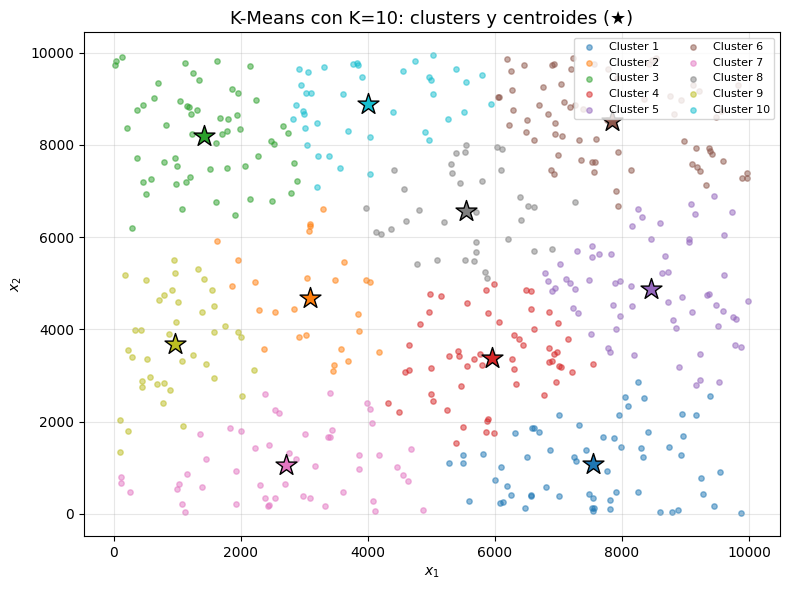

In [9]:
# Visualización de los clusters resultantes
cmap = plt.get_cmap('tab10')

plt.figure(figsize=(8, 6))
for i, cluster in enumerate(clusters):
    pts = x[cluster]
    plt.scatter(pts[:, 0], pts[:, 1], s=15, alpha=0.5, color=cmap(i), label=f'Cluster {i+1}')
    cx, cy = centroids[i]
    plt.scatter(cx, cy, s=250, marker='*', color=cmap(i), edgecolors='black', linewidths=1, zorder=5)

plt.title(f'K-Means con K={len(clusters)}: clusters y centroides (★)', fontsize=13)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.legend(ncol=2, fontsize=8, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.6 Visualización iteración por iteración

<div align='justify'>

El widget muestra el Algoritmo 10.1 paso a paso: cómo los centroides $\bar{x}_{kj}$ se desplazan en cada iteración hasta estabilizarse. El panel derecho traza la **trayectoria** de cada centroide, ilustrando la convergencia.

> Como señala ISLR, el resultado depende de la inicialización aleatoria. Por eso se recomienda ejecutar el algoritmo varias veces.

</div>


In [10]:
from ipywidgets import interact, IntSlider
from matplotlib import cm # Import cm here

# Re-ejecutar K-Means guardando historial completo
# (usamos la misma lógica que K_Means pero guardando estado por iteración)
def K_Means_historial(k, x, seed=42):
    np.random.seed(seed)
    old_clusters = [[] for _ in range(k)]
    new_clusters = [[] for _ in range(k)]
    centroid_clusters = [[] for _ in range(k)]

    for i in range(x.shape[0]):
        new_clusters[np.random.randint(k)].append(i)
    for i in range(k):
        centroid_clusters[i] = np.mean(x[new_clusters[i]], axis=0)

    historial = []
    while old_clusters != new_clusters:
        old_clusters = [i.copy() for i in new_clusters]
        new_clusters = [[] for _ in range(k)]

        for i in range(x.shape[0]):
            min_dist = np.inf
            index_cluster = 0
            for j in range(k):
                d = distance(x[i].reshape(1,-1), centroid_clusters[j].reshape(1,-1))
                if d < min_dist:
                    min_dist = d
                    index_cluster = j
            new_clusters[index_cluster].append(i)

        for i in range(k):
            if len(new_clusters[i]) > 0:
                centroid_clusters[i] = np.mean(x[new_clusters[i]], axis=0)

        # Guardar estado de esta iteración
        historial.append(
            {
                "clusters": [c.copy() for c in new_clusters],
                "centroides": [c.copy() for c in centroid_clusters]
            }
        )

    return historial

# Datos más compactos para visualización clara
np.random.seed(0)
x_vis = np.random.randint(0, 100, size=(200, 2)).astype(float)
k_vis = 5
historial = K_Means_historial(k_vis, x_vis)
# Updated to use plt.get_cmap as recommended by the deprecation warning
cmap_vis = plt.get_cmap('tab10', k_vis)

def ver_iteracion(paso):
    estado = historial[paso]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f'K-Means — Iteración {paso+1} / {len(historial)}',
        fontsize=14,
        fontweight='bold'
    )

    # Panel izquierdo: clusters en esta iteración
    ax = axes[0]
    for i in range(k_vis):
        pts = x_vis[estado["clusters"][i]]
        if len(pts): ax.scatter(pts[:, 0], pts[:, 1], s=20, alpha=0.55, color=cmap_vis(i))
        cx, cy = estado["centroides"][i]
        ax.scatter(
            cx,
            cy,
            s=280,
            marker='*',
            color=cmap_vis(i),
            edgecolors='black',
            linewidths=1,
            zorder=5,
            label=f'c{i+1}=({cx:.0f},{cy:.0f})'
        )
    ax.set_title('Asignación de puntos')
    ax.legend(fontsize=7, ncol=2)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.3)

    # Panel derecho: trayectoria de centroides
    ax2 = axes[1]
    ax2.scatter(x_vis[:, 0], x_vis[:, 1], s=10, alpha=0.2, color='gray')
    for i in range(k_vis):
        trayectoria = np.array([historial[p]["centroides"][i] for p in range(paso + 1)])
        ax2.plot(
            trayectoria[:, 0],
            trayectoria[:, 1],
            '-o',
            color=cmap_vis(i),
            linewidth=2,
            markersize=5,
            alpha=0.8
        )
        ax2.scatter(
            *trayectoria[-1],
            s=280,
            marker='*',
            color=cmap_vis(i),
            edgecolors='black',
            linewidths=1,
            zorder=5
        )
    ax2.set_title('Trayectoria de los centroides')
    ax2.set_xlabel('x₁')
    ax2.set_ylabel('x₂')
    ax2.grid(True, alpha=0.3)

    if paso == len(historial) - 1:
        fig.text(
            0.5,
            -0.02,
            '✅  Convergencia alcanzada — estos centroides son los centros de las neuronas RBF',
            ha='center',
            fontsize=11,
            color='green',
            fontstyle='italic'
        )
    plt.tight_layout()
    plt.show()

interact(
    ver_iteracion,
    paso=IntSlider(
        min=0,
        max=len(historial) - 1,
        step=1,
        value=0,
        description='Iteración:',
        style={'description_width': '80px'}
    )
);

interactive(children=(IntSlider(value=0, description='Iteración:', max=9, style=SliderStyle(description_width=…

## 5. Entrenamiento de Redes RBF: Enfoque Híbrido y Algoritmo RLS

El entrenamiento de una red neuronal de Función de Base Radial (RBF) se aborda comúnmente mediante un procedimiento híbrido en dos etapas:

1. **Primera etapa (No supervisada):** Se utiliza un método de agrupamiento, como el algoritmo de K-means, para entrenar la capa oculta de manera no supervisada y determinar los centros de las funciones de base radial.
2. **Segunda etapa (Supervisada):** Una vez establecidos los centros y definidos los mapeos no lineales del espacio de entrada hacia el espacio oculto, la capa de salida realiza un mapeo lineal. Para entrenar esta capa de salida, se implementa una técnica de estimación por mínimos cuadrados recursivos (RLS).


**Mínimos Cuadrados Recursivos (RLS)**
A diferencia del descenso de gradiente estándar, el filtro RLS minimiza la suma de los errores cuadrados de forma recursiva a medida que se presentan nuevos patrones, logrando una convergencia extremadamente rápida. En cada paso $n$, los pesos se actualizan siguiendo:

1. **Vector de ganancia:** $k(n) = \frac{\lambda^{-1} P(n-1) \phi(n)}{1 + \lambda^{-1} \phi^T(n) P(n-1) \phi(n)}$
2. **Error a priori:** $\alpha(n) = d(n) - w^T(n-1) \phi(n)$
3. **Actualización de pesos:** $w(n) = w(n-1) + k(n) \alpha(n)$
4. **Actualización de la matriz de covarianza inversa:** $P(n) = \lambda^{-1} P(n-1) - \lambda^{-1} k(n) \phi^T(n) P(n-1)$

Donde $\phi(n)$ representa el vector de salidas de la capa oculta, $d(n)$ la salida deseada, $P(n)$ la aproximación de la matriz de covarianza inversa y $\lambda$ el factor de olvido (típicamente entre 0.9 y 1.0).

In [11]:
class RBFNetworkRLS:
    """
    Implementación orientada a objetos de una Red RBF con capa de
    salida entrenada mediante Mínimos Cuadrados Recursivos (RLS).
    """
    def __init__(self, num_centers, forget_factor=0.99, delta=10.0):
        self.num_centers = num_centers
        self.centers = None
        self.sigma = None
        self.weights = None

        # Parámetros del filtro RLS
        self.lam = forget_factor
        self.delta = delta
        self.P = None

    def _rbf_activation(self, x, c, s):
        """Función de Base Radial Gaussiana."""
        return np.exp(-1 / (2 * s**2) * np.linalg.norm(x - c)**2)

    def _calculate_interpolation_matrix(self, X):
        """Calcula la matriz de diseño (Phi) de la capa oculta."""
        Phi = np.zeros((X.shape[0], self.num_centers))
        for i, x in enumerate(X):
            for j, c in enumerate(self.centers):
                Phi[i, j] = self._rbf_activation(x, c, self.sigma)
        return Phi

    def train_hidden_layer(self, X):
        """Entrenamiento no supervisado de la capa oculta mediante K-Means."""
        kmeans = KMeans(n_clusters=self.num_centers, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_

        # Heurística para sigma: distancia máxima entre centros dividida por sqrt(2*num_centers)
        d_max = np.max([np.linalg.norm(c1 - c2) for c1 in self.centers for c2 in self.centers])
        self.sigma = d_max / np.sqrt(2 * self.num_centers)

    def train_output_layer_rls(self, X, d):
        """Entrenamiento supervisado de los pesos de salida usando RLS."""
        Phi = self._calculate_interpolation_matrix(X)
        num_samples = Phi.shape[0]

        # Inicialización de pesos (w) y de la matriz de covarianza inversa (P)
        self.weights = np.zeros(self.num_centers)
        self.P = self.delta * np.eye(self.num_centers)

        for n in range(num_samples):
            phi_n = Phi[n, :].reshape(-1, 1)
            d_n = d[n]

            # Ecuaciones del filtro RLS
            num = (1 / self.lam) * np.dot(self.P, phi_n)
            den = 1 + (1 / self.lam) * np.dot(np.dot(phi_n.T, self.P), phi_n)
            k_n = num / den  # Vector de ganancia

            alpha_n = d_n - np.dot(self.weights.T, phi_n)  # Error a priori

            self.weights = self.weights + (k_n * alpha_n).flatten()  # Actualización de pesos
            self.P = (1 / self.lam) * self.P - (1 / self.lam) * np.dot(k_n, np.dot(phi_n.T, self.P))

    def predict(self, X):
        """Predice nuevos valores empleando los centros y pesos ajustados."""
        Phi = self._calculate_interpolation_matrix(X)
        return np.dot(Phi, self.weights)

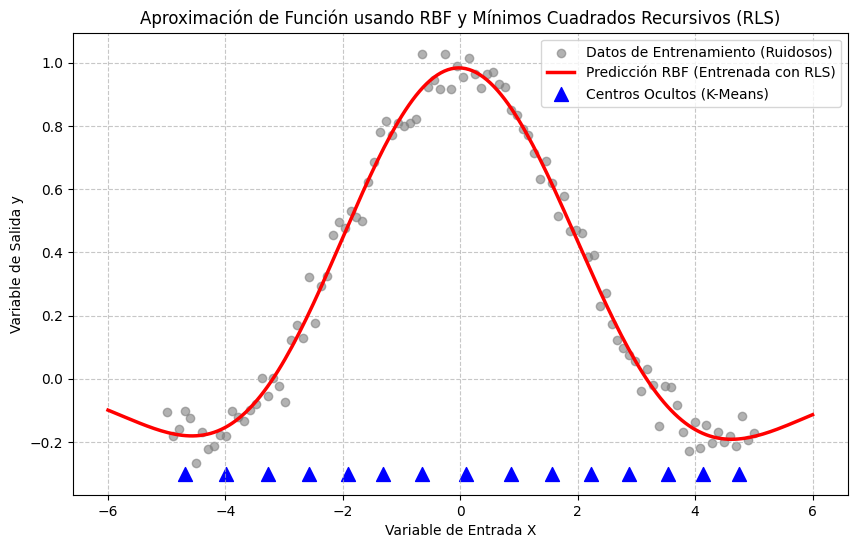

In [12]:
# 1. Generación de datos sintéticos no lineales (Aproximación de una función con ruido)
np.random.seed(0)
X_train = np.linspace(-5, 5, 100).reshape(-1, 1)
# Función sinc con ruido añadido
y_train = np.sin(X_train).flatten() / X_train.flatten() + np.random.normal(0, 0.05, 100)

# 2. Instanciación y flujo de entrenamiento por etapas
rbf_rls = RBFNetworkRLS(num_centers=15, forget_factor=1.0) # lambda=1.0 asume sistema estacionario
rbf_rls.train_hidden_layer(X_train)
rbf_rls.train_output_layer_rls(X_train, y_train)

# 3. Evaluación del modelo
X_test = np.linspace(-6, 6, 200).reshape(-1, 1)
y_pred = rbf_rls.predict(X_test)

# 4. Visualización
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='gray', alpha=0.6, label='Datos de Entrenamiento (Ruidosos)')
plt.plot(X_test, y_pred, color='red', linewidth=2.5, label='Predicción RBF (Entrenada con RLS)')
plt.scatter(rbf_rls.centers, np.zeros_like(rbf_rls.centers)-0.3, color='blue', marker='^', s=100, label='Centros Ocultos (K-Means)')
plt.title('Aproximación de Función usando RBF y Mínimos Cuadrados Recursivos (RLS)')
plt.xlabel('Variable de Entrada X')
plt.ylabel('Variable de Salida y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
def RLS(x, d):
  """Ejecuta el algoritmo RLS para hallar los pesos entre la capa oculta y la capa de salida"""
  lambda_value = 0.1

  w = np.zeros(x.shape[0])
  P = (1/lambda_value) * np.identity(x.shape[0])

  for i in range(x.shape[1]):
    P = P - ((P @ np.outer(x[:, i], x[:, i].T) @ P)/(1 + x[:, i].T @ P @ x[:, i]))
    g = np.dot(P, x[:, i])
    a = d[i] - w.T @ x[:,i]
    w = w + g * a

  return w


## 6. Ejemplo 1

Para esta implementacion se buscara que la red neuronal de funciones de base radial realice un trabajo de regresion para la funcion $ \frac{x^2 + y^2}{50} $. Se entranaran diferentes RBF usando distintas cantidades de neuronas en la capa oculta (5, 10, 15 y 20) con el fin de ver como afecta esto a la precision de la red. La implementacion de la red neurnal usara funciones gaussianas donde el valor sigma se calculara usando la siguiente formula propuesta por Haykin:

$$
σ=\frac{d_{max}}{\sqrt{2K}}
$$

$d$: Distancia maxima entre los centros  
$K$: Numero de centros (clusters)




In [14]:
def hidden_layer_output(x, centers, sigma):
  """Calcula la salida de la capa oculta"""
  gaussian_result = []
  for i in centers:
    gaussian_result.append(gaussian(x, i, sigma))

  return gaussian_result

def calc_sigma(centroids):
  """Calcula el valor de sigma (valor necesario para calcular la funcion Gaussiana)"""
  max = 0
  for i in centroids:
    for j in centroids:
      if np.linalg.norm(i - j) > max:
        max = np.linalg.norm(i - j)
  return max / (np.sqrt(2*len(centroids)))

In [15]:
# Generacion de datos

input_data = [[],[]]

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

for i in x:
  for j in y:
    input_data[0].append(i)
    input_data[1].append(j)

input_data = np.array(input_data).T

output_data = (input_data[:,0]**2 + input_data[:,1]**2)/50


# Entrenamiento no supervisado para calcular los centroides (K-Means) para 5, 10, 15 y 20 neuronas

clusters_5N, centroids_5N = K_Means(5, input_data)
clusters_10N, centroids_10N = K_Means(10, input_data)
clusters_15N, centroids_15N = K_Means(15, input_data)
clusters_20N, centroids_20N = K_Means(20, input_data)

sigma_5N = calc_sigma(centroids_5N)
sigma_10N = calc_sigma(centroids_10N)
sigma_15N = calc_sigma(centroids_15N)
sigma_20N = calc_sigma(centroids_20N)

output_hidden_layer_5N = hidden_layer_output(input_data, centroids_5N, sigma_5N)
output_hidden_layer_10N = hidden_layer_output(input_data, centroids_10N, sigma_10N)
output_hidden_layer_15N = hidden_layer_output(input_data, centroids_15N, sigma_15N)
output_hidden_layer_20N = hidden_layer_output(input_data, centroids_20N, sigma_20N)

# Entrenamiento supervisado para calcular los pesos usando RLS para 5, 10, 15 y 20 neuronas

w_5N = RLS(np.array(output_hidden_layer_5N), output_data)
w_10N = RLS(np.array(output_hidden_layer_10N), output_data)
w_15N = RLS(np.array(output_hidden_layer_15N), output_data)
w_20N = RLS(np.array(output_hidden_layer_20N), output_data)

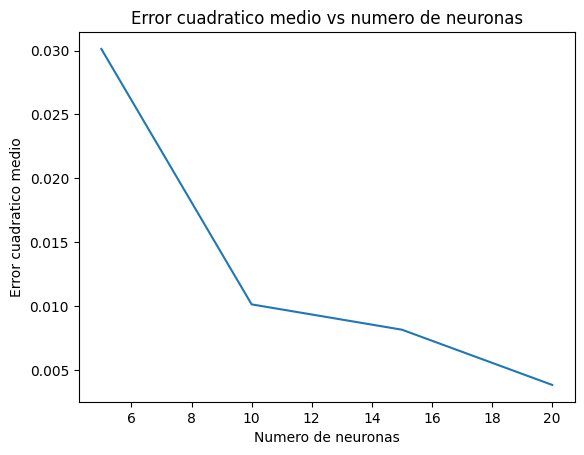

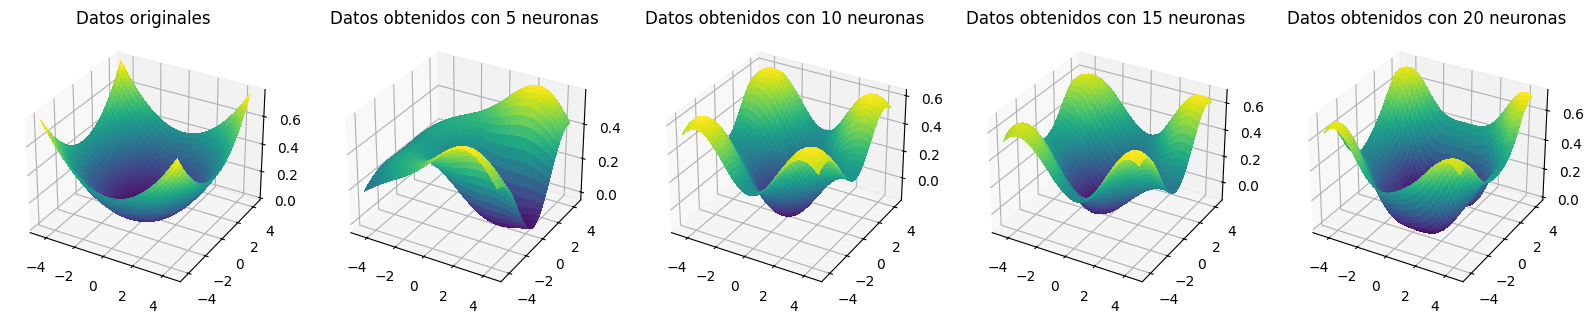

In [16]:
from matplotlib import cm

# Generacion de datos de validacion

testX = np.linspace(-4.5, 4.5, 100)
testY = np.linspace(-4.3, 4.3, 70)
input_training = [[], []]

for i in testX:
  for j in testY:
    input_training[0].append(i)
    input_training[1].append(j)

input_training = np.array(input_training).T

output_training = (input_training[:,0]**2 + input_training[:,1]**2)/50

# Calculo de la salidas de la red neuronal variando la cantidad de neuronas (5, 10, 15 y 20)

result_5N = np.array(hidden_layer_output(input_training, centroids_5N, sigma_5N)).T @ w_5N
result_10N = np.array(hidden_layer_output(input_training, centroids_10N, sigma_10N)).T @ w_10N
result_15N = np.array(hidden_layer_output(input_training, centroids_15N, sigma_15N)).T @ w_15N
result_20N = np.array(hidden_layer_output(input_training, centroids_20N, sigma_20N)).T @ w_20N

# Calculo del error cuadratico medio

mse_5N = np.mean((output_training - result_5N)**2)
mse_10N = np.mean((output_training - result_10N)**2)
mse_15N = np.mean((output_training - result_15N)**2)
mse_20N = np.mean((output_training - result_20N)**2)

# Reorganizacion de los datos para graficar las superficies y los errores cuadraticos medios

X, Y = np.meshgrid(testX, testY)

Z_real = output_training.reshape(len(testX), len(testY)).T

Z_5N  = result_5N.reshape(len(testX), len(testY)).T
Z_10N = result_10N.reshape(len(testX), len(testY)).T
Z_15N = result_15N.reshape(len(testX), len(testY)).T
Z_20N = result_20N.reshape(len(testX), len(testY)).T

plt.figure()
plt.plot(np.array([5, 10, 15, 20]), np.array([mse_5N, mse_10N, mse_15N, mse_20N]))
plt.xlabel("Numero de neuronas")
plt.ylabel("Error cuadratico medio")
plt.title("Error cuadratico medio vs numero de neuronas")
plt.show()

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, ncols=5, figsize=(20,4))
ax[0].plot_surface(X, Y, Z_real, cmap=cm.viridis, antialiased=False)
ax[0].set_title("Datos originales")

ax[1].plot_surface(X, Y, Z_5N, cmap=cm.viridis, antialiased=False)
ax[1].set_title("Datos obtenidos con 5 neuronas")

ax[2].plot_surface(X, Y, Z_10N, cmap=cm.viridis, antialiased=False)
ax[2].set_title("Datos obtenidos con 10 neuronas")

ax[3].plot_surface(X, Y, Z_15N, cmap=cm.viridis, antialiased=False)
ax[3].set_title("Datos obtenidos con 15 neuronas")

ax[4].plot_surface(X, Y, Z_20N, cmap=cm.viridis, antialiased=False)
ax[4].set_title("Datos obtenidos con 20 neuronas")

plt.show()

## 7. Ejemplo 2: RBF Network aplicada a MNIST

En este ejemplo aplicamos una Radial Basis Function Neural Network al dataset MNIST para clasificación de dígitos.

1. Se seleccionan centros RBF mediante K-Means.
2. Cada neurona oculta calcula una función gaussiana respecto a su centro.
3. Esto genera una matriz de activación Φ.
4. Los pesos de la capa de salida se obtienen resolviendo un problema de mínimos cuadrados.

Este enfoque transforma el problema en un modelo lineal en el espacio generado por las funciones radiales.

### Carga dataset MNIST

In [17]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Cargar MNIST
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values
y = mnist.target.astype(int).values

# Normalizar
X = X / 255.0

# Usar subconjunto para que sea más rápido
X = X[:10000]
y = y[:10000]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 784)
Test shape: (2000, 784)


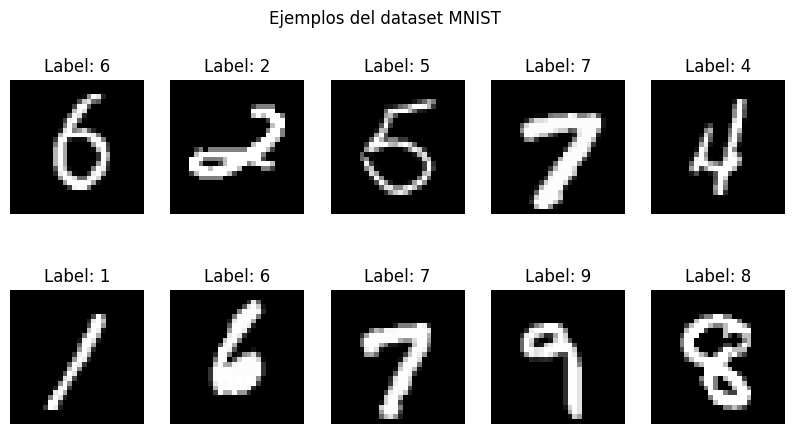

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28,28), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.suptitle("Ejemplos del dataset MNIST")
plt.show()

### Encontrar centros RBF con K-Means

In [19]:
from sklearn.cluster import KMeans

num_centers = 100

kmeans = KMeans(n_clusters=num_centers, random_state=0)
kmeans.fit(X_train)

centers = kmeans.cluster_centers_

print("Centros RBF:", centers.shape)

Centros RBF: (100, 784)


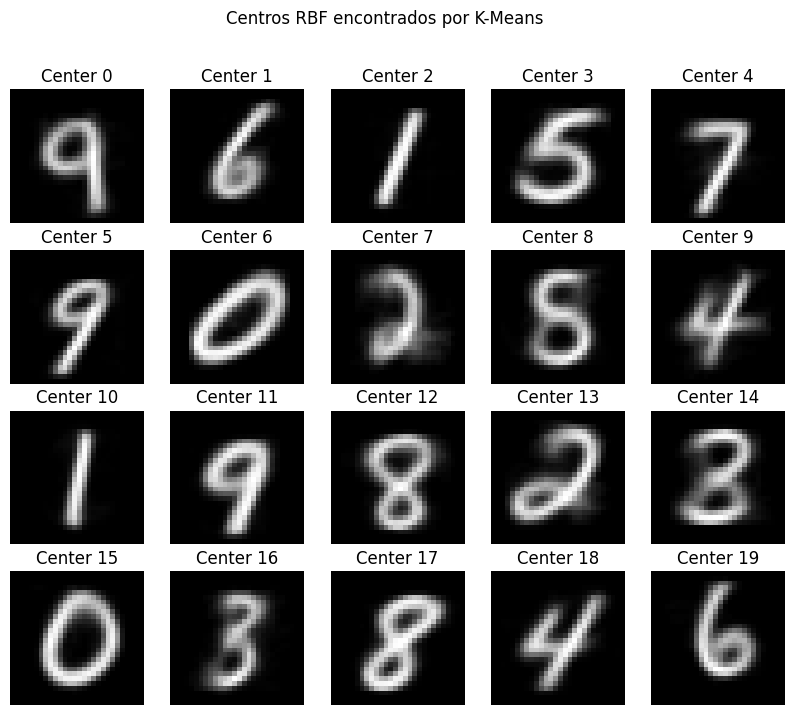

In [20]:
fig, axes = plt.subplots(4, 5, figsize=(10,8))

for i, ax in enumerate(axes.flat):
    if i < len(centers):
        ax.imshow(centers[i].reshape(28,28), cmap='gray')
        ax.set_title(f"Center {i}")
        ax.axis("off")

plt.suptitle("Centros RBF encontrados por K-Means")
plt.show()

### Calcular sigma

In [21]:
sigma = calc_sigma(centers)

print("Sigma:", sigma)

Sigma: 0.790890447470845


### Calcular la salida de la capa oculta

In [22]:
def rbf_layer(X, centers, sigma):

    Phi = np.zeros((X.shape[0], len(centers)))

    for i, c in enumerate(centers):
        Phi[:, i] = gaussian(X, c, sigma)

    return Phi

Phi_train = rbf_layer(X_train, centers, sigma)
Phi_test = rbf_layer(X_test, centers, sigma)

print(Phi_train.shape)

(8000, 100)


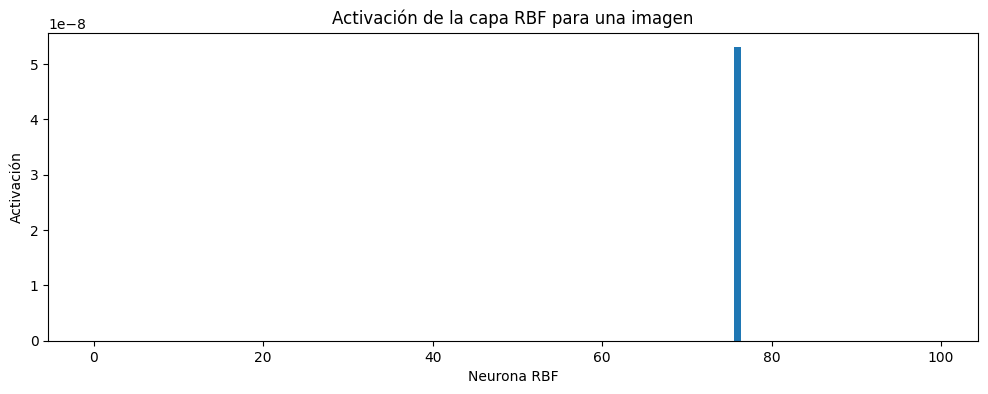

In [23]:
sample_index = 0

plt.figure(figsize=(12,4))
plt.bar(range(Phi_train.shape[1]), Phi_train[sample_index])
plt.xlabel("Neurona RBF")
plt.ylabel("Activación")
plt.title("Activación de la capa RBF para una imagen")
plt.show()

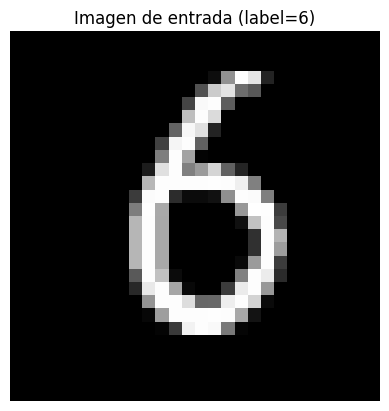

In [24]:
plt.imshow(X_train[sample_index].reshape(28,28), cmap='gray')
plt.title(f"Imagen de entrada (label={y_train[sample_index]})")
plt.axis("off")
plt.show()

### One-Hot encoding de etiquetas

In [25]:
num_classes = 10

Y_train = np.zeros((y_train.size, num_classes))
Y_train[np.arange(y_train.size), y_train] = 1

### Entrenar capa de salida (mínimos cuadrados)

In [26]:
W = np.linalg.pinv(Phi_train) @ Y_train

print("Shape pesos:", W.shape)

Shape pesos: (100, 10)


### Predicción

In [27]:
scores = Phi_test @ W
y_pred = np.argmax(scores, axis=1)

### Evaluar precisión

In [28]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.8495


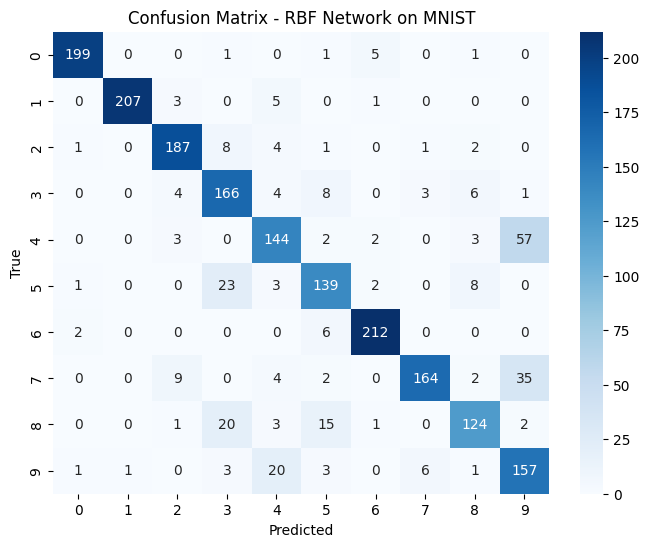

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - RBF Network on MNIST")

plt.show()

### Visualización resultados

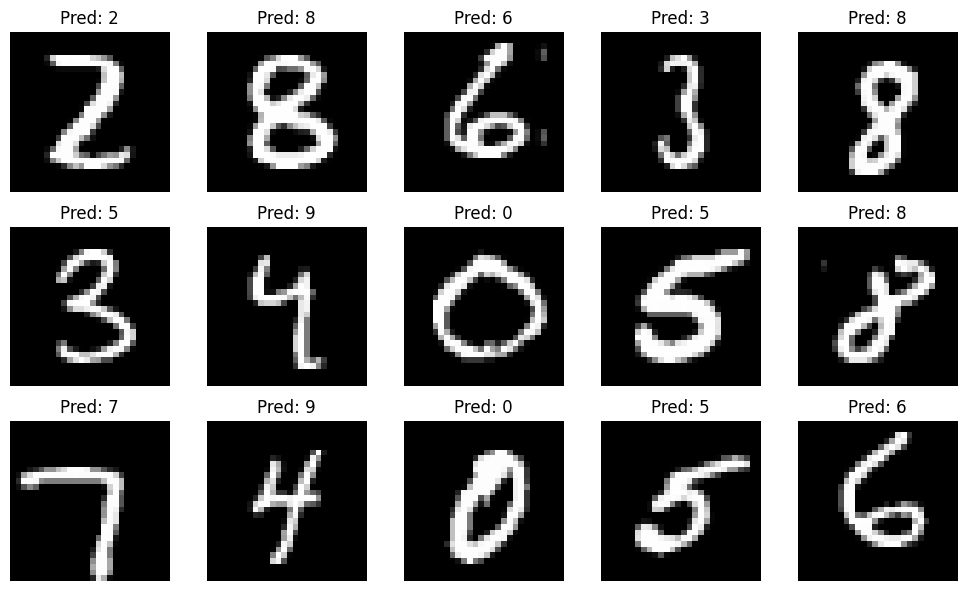

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3,5, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Referencias

* Cloud Software Group, SANN Overviews - Network types., 2021
* S. Haykin, Neural Networks and Learning Machines, 3a ed. Pearson, 2009
* G. James, D. Witten, T. Hastie, y R. Tibshirani, An introduction to statistical learning: With applications in R. Springer, 2013.